# 02: Estimates — Author's replication and extension

Loads `outputs/py/dk_clean.parquet`. Sections: incidence; replication of the
reported D&K rows 1–4 (1983–2000); the author's model by pooled period, by
period, and single year (Author's Replication 1983–2000, Author's Extension
2001–2025); summary statistics; quarterly estimates. Union mediation is in
`06_unionmediation`.

The author's model is the D&K row-1 wage regression without `gov_employee`.
`gov_employee` is not in any model; it appears only in the descriptive summary
statistics.

Sources: `refs/dk_spec.md`, `refs/author_spec.md`, `refs/cleaning.md` govern the
model/sample/variable definitions; `CLAUDE.md` governs output conventions
(long-format estimates, `outputs/py/`, `outputs/figures/`).

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pyfixest as pf

os.makedirs("../outputs/py", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

dk_clean = pd.read_parquet("../outputs/py/dk_clean.parquet")
dk_published_penalty = pd.read_csv("../data/comparisons/dk_published_penalty.csv")
print(dk_clean.shape)

(166391, 49)


## 1. Incidence of outsourcing

Source: `refs/dk_spec.md`, "## Incidence of outsourcing (D&K Table 1)".
Incidence has no covariates, so it does not depend on the model —
computed once here.

Benchmark: `data/comparisons/dk_published_incidence.csv` (role: benchmark,
hand-entered from D&K Table 1). That file has no standard errors and no
change-row value, so this notebook reports its own SEs/change row without
inventing a D&K figure to compare them to (per `refs/dk_spec.md`: "these
files are the only source of D&K values; never invent others").

In [39]:
def weighted_incidence(g):
    # share = sum(EARNWT * outsourced) / sum(EARNWT); se = binomial SE with
    # Kish effective N (refs/dk_spec.md, replication choice)
    w = g["EARNWT"].to_numpy(dtype=float)
    o = g["outsourced"].to_numpy(dtype=float)
    share = np.sum(w * o) / np.sum(w)
    n_eff = (np.sum(w) ** 2) / np.sum(w ** 2)
    se = np.sqrt(share * (1 - share) / n_eff)
    return pd.Series({"share": share, "se": se, "n": int((g["EARNWT"] > 0).sum()), "n_eff": n_eff})

incidence_annual = (
    dk_clean.groupby(["occupation", "YEAR"])
    .apply(weighted_incidence, include_groups=False)
    .reset_index()
)
incidence_annual["ci_lo"] = incidence_annual["share"] - 1.96 * incidence_annual["se"]
incidence_annual["ci_hi"] = incidence_annual["share"] + 1.96 * incidence_annual["se"]
print(incidence_annual.shape)
incidence_annual.head()

(84, 8)


,occupation,YEAR,share,se,n,n_eff,ci_lo,ci_hi
0,guard,1983,0.360568,0.016018,1094.0,898.583777,0.329173,0.391964
1,guard,1984,0.363815,0.016222,1076.0,879.508025,0.332019,0.395610
2,guard,1985,0.383748,0.016141,1120.0,907.649535,0.352111,0.415385
3,guard,1986,0.366503,0.015570,1155.0,957.787104,0.335987,0.397019
4,guard,1987,0.396440,0.015842,1184.0,953.394947,0.365389,0.427490


In [40]:
# D&K Table 1: 3-year bins, 1983-2000, plus a change row (share(1998-2000) - share(1983-85))
dk_bins = [(1983, 1985), (1986, 1988), (1989, 1991), (1992, 1994), (1995, 1997), (1998, 2000)]

def bin_incidence(occ, y0, y1):
    g = dk_clean[(dk_clean["occupation"] == occ) & dk_clean["YEAR"].between(y0, y1)]
    return {"occ": occ, "year_start": y0, "year_end": y1, **weighted_incidence(g)}

incidence_bins = pd.DataFrame(
    [bin_incidence(occ, y0, y1) for occ in ["janitor", "guard"] for (y0, y1) in dk_bins]
)
incidence_bins["label"] = (
    incidence_bins["year_start"].astype(int).astype(str) + "-" + incidence_bins["year_end"].astype(int).astype(str)
)

change_rows = []
for occ in ["janitor", "guard"]:
    s1 = incidence_bins[(incidence_bins["occ"] == occ) & (incidence_bins["year_start"] == 1983)].iloc[0]
    s2 = incidence_bins[(incidence_bins["occ"] == occ) & (incidence_bins["year_start"] == 1998)].iloc[0]
    change_rows.append({
        "occ": occ, "year_start": np.nan, "year_end": np.nan,
        "share": s2["share"] - s1["share"],
        "se": np.sqrt(s1["se"] ** 2 + s2["se"] ** 2),
        "n": np.nan, "n_eff": np.nan, "label": "change (1998-2000 minus 1983-85)",
    })
incidence_bins = pd.concat([incidence_bins, pd.DataFrame(change_rows)], ignore_index=True)
print(incidence_bins.round(4))

        occ  year_start  year_end   share      se        n      n_eff  \
0   janitor      1983.0    1985.0  0.1316  0.0036  11554.0  9061.8145   
1   janitor      1986.0    1988.0  0.1505  0.0039  10937.0  8374.2747   
2   janitor      1989.0    1991.0  0.1643  0.0041  10732.0  8091.2706   
3   janitor      1992.0    1994.0  0.1832  0.0045   9716.0  7239.0679   
4   janitor      1995.0    1997.0  0.1899  0.0047   8798.0  6839.0536   
5   janitor      1998.0    2000.0  0.1772  0.0046   8590.0  6783.8443   
6     guard      1983.0    1985.0  0.3696  0.0093   3290.0  2685.4273   
7     guard      1986.0    1988.0  0.3820  0.0094   3433.0  2682.3576   
8     guard      1989.0    1991.0  0.3952  0.0096   3293.0  2567.6270   
9     guard      1992.0    1994.0  0.4326  0.0099   3312.0  2514.0624   
10    guard      1995.0    1997.0  0.4714  0.0105   2844.0  2277.5899   
11    guard      1998.0    2000.0  0.4715  0.0103   2866.0  2343.4501   
12  janitor         NaN       NaN  0.0456  0.0058  

In [41]:
# Comparison table: my 3-year bins vs. D&K published Table 1
dk_published_incidence = pd.read_csv("../data/comparisons/dk_published_incidence.csv")
occ_map = {"janitor": "Janitors", "guard": "Guards"}

mine = incidence_bins[incidence_bins["label"] != "change (1998-2000 minus 1983-85)"].copy()
mine["occ_label"] = mine["occ"].map(occ_map)
mine["year_start"] = mine["year_start"].astype(int)
mine["year_end"] = mine["year_end"].astype(int)

bench = dk_published_incidence.rename(columns={"occ": "occ_label", "share": "dk_share"})
incidence_comparison = mine.merge(bench, on=["occ_label", "year_start", "year_end"], how="left")
incidence_comparison["diff"] = incidence_comparison["share"] - incidence_comparison["dk_share"]
incidence_comparison = incidence_comparison[
    ["occ", "year_start", "year_end", "share", "se", "dk_share", "diff"]
].rename(columns={"share": "my_share", "se": "my_se"})
print(incidence_comparison.round(4).to_string(index=False))

    occ  year_start  year_end  my_share  my_se  dk_share    diff
janitor        1983      1985    0.1316 0.0036     0.164 -0.0324
janitor        1986      1988    0.1505 0.0039     0.182 -0.0315
janitor        1989      1991    0.1643 0.0041     0.210 -0.0457
janitor        1992      1994    0.1832 0.0045     0.227 -0.0438
janitor        1995      1997    0.1899 0.0047     0.231 -0.0411
janitor        1998      2000    0.1772 0.0046     0.216 -0.0388
  guard        1983      1985    0.3696 0.0093     0.401 -0.0314
  guard        1986      1988    0.3820 0.0094     0.411 -0.0290
  guard        1989      1991    0.3952 0.0096     0.424 -0.0288
  guard        1992      1994    0.4326 0.0099     0.462 -0.0294
  guard        1995      1997    0.4714 0.0105     0.497 -0.0256
  guard        1998      2000    0.4715 0.0103     0.497 -0.0255


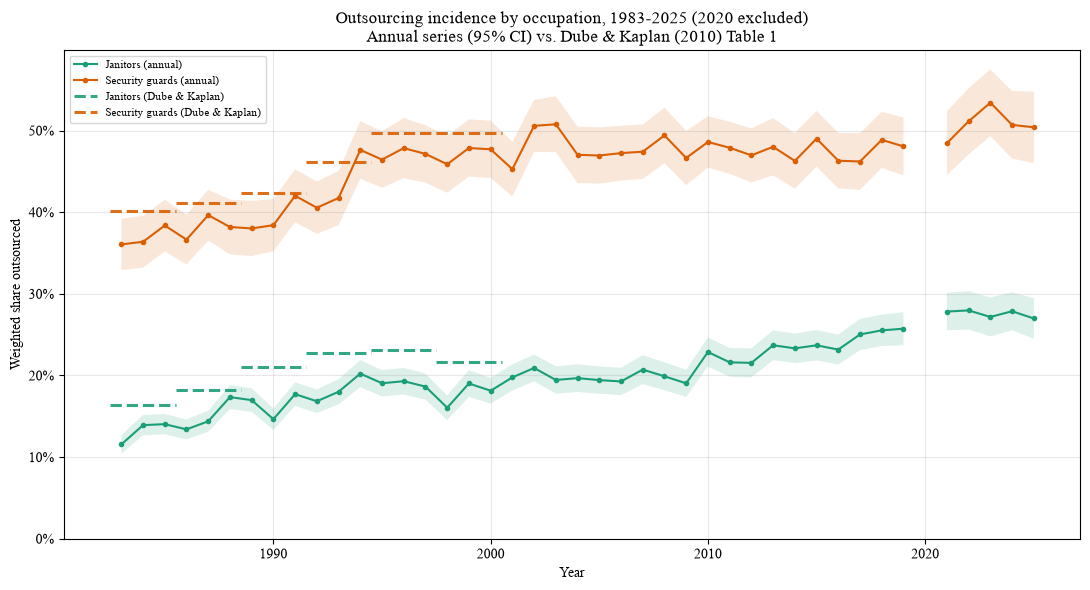

In [42]:
plt.rcParams["font.family"] = ["Times New Roman", "Times", "serif"]

# Annual series with 95% CIs, line broken at 2020, D&K Table 1 shares as horizontal
# segments over their periods
years_full = pd.Index(range(1983, 2026), name="YEAR")
wide_share = incidence_annual.pivot(index="YEAR", columns="occupation", values="share").reindex(years_full)
wide_se = incidence_annual.pivot(index="YEAR", columns="occupation", values="se").reindex(years_full)

occ_labels = {"janitor": "Janitors", "guard": "Security guards"}
dk_occ_key = {"Janitors": "janitor", "Guards": "guard"}
colors = {"janitor": "#1b9e77", "guard": "#d95f02"}

fig, ax = plt.subplots(figsize=(11, 6))
for occ in ["janitor", "guard"]:
    share, se = wide_share[occ], wide_se[occ]
    ax.plot(years_full, share, marker="o", markersize=3, linewidth=1.5,
            color=colors[occ], label=f"{occ_labels[occ]} (annual)")
    ax.fill_between(years_full, share - 1.96 * se, share + 1.96 * se,
                    color=colors[occ], alpha=0.15, linewidth=0)

first_seg = {"janitor": True, "guard": True}
for _, row in dk_published_incidence.iterrows():
    occ = dk_occ_key[row["occ"]]
    lab = f"{occ_labels[occ]} (Dube & Kaplan)" if first_seg[occ] else None
    first_seg[occ] = False
    # span each bin's full width: e.g., 1983-1985 runs from 1982.5 to 1985.5
    ax.plot([row["year_start"] - 0.5, row["year_end"] + 0.5], [row["share"], row["share"]],
            color=colors[occ], linestyle="--", linewidth=2.2, alpha=0.9, label=lab)

ax.set_xlabel("Year")
ax.set_ylabel("Weighted share outsourced")
ax.set_title("Outsourcing incidence by occupation, 1983-2025 (2020 excluded)\n"
             "Annual series (95% CI) vs. Dube & Kaplan (2010) Table 1")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0, None)
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

fig.savefig("../outputs/figures/figure1_incidence_annual.png", dpi=300)
plt.show()

In [43]:
incidence_annual.to_csv("../outputs/py/incidence_annual.csv", index=False)
incidence_bins.to_csv("../outputs/py/incidence_table1_bins.csv", index=False)
incidence_comparison.to_csv("../outputs/py/incidence_table1_vs_dk.csv", index=False)
print("saved incidence outputs")

saved incidence outputs


## Shared setup: formulas, terms, and a long-format recorder

Used by sections 2–6. `fit_and_record` fits a model, appends every
coefficient to `master` (the accumulator saved as `outputs/py/estimates.csv`
at the end, in `CLAUDE.md`'s long format: `lang, spec, model, occ, sample,
term, estimate, se, t, p, n_obs`), and caches the fit + its sample in
`fit_cache` so later sections can reuse it instead of refitting.

In [ ]:
author_terms = ["log_wage", "outsourced", "union", "parttime", "educ_cat", "female", "black",
                "hispanic", "age", "age2", "msa", "central_city", "cc_unknown", "geo_unidentified"]
nofemale_terms = [t for t in author_terms if t != "female"]
nounion_terms = [t for t in author_terms if t != "union"]

author_formula = (
    "log_wage ~ outsourced + union + parttime + educ_cat + female + black + hispanic "
    "+ age + age2 + msa + central_city + cc_unknown + geo_unidentified | STATEFIP^YEAR"
)
nofemale_formula = author_formula.replace("female + ", "")
interact_formula = author_formula.replace(" | STATEFIP^YEAR", " + union_x_outsourced + parttime_x_outsourced | STATEFIP^YEAR")
nounion_formula = author_formula.replace("outsourced + union + parttime", "outsourced + parttime")

master = []     # long-format accumulator across all sections
fit_cache = {}  # (occ, spec, model, sample) -> (fit, sample_df)

def record(fit, lang, spec, model, occ, sample):
    t = fit.tidy().reset_index()
    for _, r in t.iterrows():
        master.append(dict(lang=lang, spec=spec, model=model, occ=occ, sample=sample,
                            term=r["Coefficient"], estimate=r["Estimate"], se=r["Std. Error"],
                            t=r["t value"], p=r["Pr(>|t|)"], n_obs=fit._N))

def fit_and_record(formula, data, terms, lang, spec, model, occ, sample):
    s = data.dropna(subset=terms).copy()
    fit = pf.feols(formula, data=s, weights="EARNWT", vcov={"CRV1": "ym"})
    record(fit, lang, spec, model, occ, sample)
    fit_cache[(occ, spec, model, sample)] = (fit, s)
    return fit, s

## 2. Replication of D&K rows 1–4, 1983–2000

Source: `refs/dk_spec.md`, "## Wage regression", "## Additional D&K rows
replicated (1983-2000 only)", and "## D&K published benchmarks".

**Rows:** 1 = baseline formula, full sample. 2 = formula minus `female`,
women only. 3 = formula minus `female`, men only. 4 = formula plus
`union_x_outsourced` and `parttime_x_outsourced`.

Benchmark: `data/comparisons/dk_published_penalty.csv` (D&K Tables 3a/3b,
rows 1–9; only rows 1–4 used here).

**Sample labels** follow `CLAUDE.md`'s Outputs section: `"1983-2000"` for
rows 1/4, `"1983-2000_female"` / `"1983-2000_male"` for rows 2/3.

**N check:** `refs/dk_spec.md` says to check N against the benchmark before
comparing coefficients. N is `fit._N` (after pyfixest drops singleton fixed effects). Three candidate explanations are reported below for
the gap found — local-government exclusion (the deferred issue in
`CLAUDE.md`), allocated/imputed earnings (untestable here — no allocation
flag in the extract), and geography complete cases (a documented choice in
`refs/dk_spec.md`) — without ranking them; the cause is not established.

**Sex-split rows (2–3), reported unpaired:** our female and male subsamples are
listed alongside D&K rows 2–3 with their published labels, without matching
labels. `refs/dk_spec.md` ("Known inconsistencies") says the janitor sex
composition in the paper is inconsistent with the CPS, so these rows are not
paired with specific D&K rows.

In [ ]:
author_samples = {}
for occ in ["janitor", "guard"]:
    s = dk_clean[(dk_clean["occupation"] == occ) & dk_clean["replication_sample"]].dropna(subset=author_terms).copy()
    author_samples[occ] = s

bench_n = dk_published_penalty[dk_published_penalty["row"] == 1][["occ", "n"]].drop_duplicates()

In [ ]:
# N-gap candidates -- reported neutrally; do not adjust cleaning/spec to close the gap,
# and do not conclude which candidate (if any) is the cause. N is fit._N (post-singleton-drop).
def fit_n(formula, sub):
    return pf.feols(formula, data=sub, weights="EARNWT", vcov={"CRV1": "ym"})._N

formula_geo = author_formula.replace(" + cc_unknown + geo_unidentified", "")
terms_geo = [t for t in author_terms if t not in ("cc_unknown", "geo_unidentified")]
for occ in ["janitor", "guard"]:
    s = author_samples[occ]
    geo = s[(s["cc_unknown"] == 0) & (s["geo_unidentified"] == 0)]
    nonlocal_gov = s[s["CLASSWKR"] != 28]
    n_full = fit_n(author_formula, s.dropna(subset=author_terms))
    n_geo = fit_n(formula_geo, geo.dropna(subset=terms_geo))
    n_nlg = fit_n(author_formula, nonlocal_gov.dropna(subset=author_terms))
    print(f"{occ}: full N={n_full} | excl. unidentified/unknown geography: {n_geo} "
          f"| excl. local government (CLASSWKR==28): {n_nlg}")

In [ ]:
# Context for the sex-label swap (not a re-derivation -- refs/dk_spec.md already settles it)
for occ in ["janitor", "guard"]:
    fshare = np.average(author_samples[occ]["female"], weights=author_samples[occ]["EARNWT"])
    print(f"{occ}: weighted female share (1983-2000 regression sample) = {fshare:.4f}")

janitor: weighted female share (1983-2000 regression sample) = 0.3095
guard: weighted female share (1983-2000 regression sample) = 0.1606


In [ ]:
for occ in ["janitor", "guard"]:
    s = author_samples[occ]
    fit_and_record(author_formula, s, author_terms, "python", "author", "base", occ, "1983-2000")
    fit_and_record(nofemale_formula, s[s["female"] == 1], nofemale_terms, "python", "author", "base", occ, "1983-2000_female")
    fit_and_record(nofemale_formula, s[s["female"] == 0], nofemale_terms, "python", "author", "base", occ, "1983-2000_male")
    fit_and_record(interact_formula, s, author_terms, "python", "author", "interactions", occ, "1983-2000")

estimates_s2 = pd.DataFrame(master)  # snapshot; sections 3-6 keep appending to `master`
print(estimates_s2.shape)

# N check against the D&K row-1 N, using the fitted model's N (fit._N)
for occ in ["janitor", "guard"]:
    my_n = fit_cache[(occ, "author", "base", "1983-2000")][0]._N
    dk_n = bench_n.loc[bench_n["occ"] == occ.capitalize() + "s", "n"].iloc[0]
    print(f"{occ}: my N (fit._N) = {my_n}, D&K row-1 N = {dk_n}, ratio = {my_n / dk_n:.2f}x")

In [ ]:
# Confirm college is the omitted educ_cat level, and cc_unknown/geo_unidentified are
# in the model, by inspecting the full row-1 coefficient table for each occupation.
for occ in ["janitor", "guard"]:
    names = fit_cache[(occ, "author", "base", "1983-2000")][0]._coefnames
    print(occ, "college omitted:", "educ_cat[T.college]" not in names,
          "| cc_unknown present:", "cc_unknown" in names,
          "| geo_unidentified present:", "geo_unidentified" in names)

janitor college omitted: True | cc_unknown present: True | geo_unidentified present: True
guard college omitted: True | cc_unknown present: True | geo_unidentified present: True


In [ ]:
# Benchmark comparison: map each (sample, model) to the matching D&K row number. Sex-split
# subsamples have no row here (reported unpaired below, per refs/dk_spec.md).
def benchmark_row(occ, sample, model):
    if sample == "1983-2000" and model == "base":
        return 1
    if sample == "1983-2000" and model == "interactions":
        return 4
    if sample in ("1983-2000_female", "1983-2000_male"):
        return np.nan
    raise ValueError((sample, model))

estimates_s2 = estimates_s2.copy()
estimates_s2["benchmark_row"] = estimates_s2.apply(lambda r: benchmark_row(r["occ"], r["sample"], r["model"]), axis=1)
estimates_s2["occ_label"] = estimates_s2["occ"].map({"janitor": "Janitors", "guard": "Guards"})

bench = dk_published_penalty.rename(columns={"estimate": "dk_estimate", "se": "dk_se", "n": "dk_n", "label": "dk_label"})
rows1_4_vs_dk = estimates_s2.merge(
    bench, left_on=["occ_label", "benchmark_row", "term"], right_on=["occ", "row", "term"],
    how="left", suffixes=("", "_bench"),
)
rows1_4_vs_dk["diff"] = rows1_4_vs_dk["estimate"] - rows1_4_vs_dk["dk_estimate"]
display_cols = ["occ", "model", "sample", "benchmark_row", "dk_label", "term",
                 "estimate", "se", "dk_estimate", "dk_se", "diff", "n_obs", "dk_n"]
print(rows1_4_vs_dk[display_cols].round(4).to_string(index=False))

In [ ]:
# Sex-split rows, reported unpaired: our female and male subsamples next to D&K rows 2-3,
# each with its own label. No label matching (refs/dk_spec.md, Known inconsistencies).
ours_sex = estimates_s2[estimates_s2["sample"].isin(["1983-2000_female", "1983-2000_male"])
                        & (estimates_s2["model"] == "base")][["occ", "sample", "term", "estimate", "se", "n_obs"]]
print("Author's sex-split subsamples (fit._N):")
print(ours_sex.round(4).to_string(index=False))
dk_sex = dk_published_penalty[dk_published_penalty["row"].isin([2, 3])][["occ", "row", "label", "term", "estimate", "se", "n"]]
print("\nD&K rows 2-3 as published (no pairing):")
print(dk_sex.round(4).to_string(index=False))

In [52]:
rows1_4_vs_dk.to_csv("../outputs/py/rows1_4_vs_dk.csv", index=False)
print("saved rows1_4_vs_dk.csv (new file -- outputs/py/dk_validation_vs_dk.csv from the prior review is left untouched)")

saved rows1_4_vs_dk.csv (new file -- outputs/py/dk_validation_vs_dk.csv from the prior review is left untouched)


## 2a. Figure: D&K reported vs. Author's Replication, 1983–2000

Outsourced coefficient (row 1, pooled 1983–2000) for each occupation: D&K reported values from
`data/comparisons/dk_published_penalty.csv` against the author's base estimate from `outputs/py/estimates.csv`.
Bars are point estimates; whiskers are 95% CIs (±1.96 SE). Output: `outputs/figures/figureB_penalty_dk_vs_replication.png`.

In [ ]:
# Figure: D&K reported vs. Author's Replication, pooled 1983-2000, outsourced coefficient (row 1)
plt.rcParams["font.family"] = ["Times New Roman", "Times", "serif"]

saved_est = pd.read_csv("../outputs/py/estimates.csv")
rep_rows = saved_est[(saved_est["spec"] == "author") & (saved_est["model"] == "base")
                     & (saved_est["sample"] == "1983-2000") & (saved_est["term"] == "outsourced")]
dk_rows = dk_published_penalty[(dk_published_penalty["row"] == 1) & (dk_published_penalty["term"] == "outsourced")]

cats = [("guard", "Guards"), ("janitor", "Janitors")]
dk_est = np.array([dk_rows.loc[dk_rows["occ"] == lab, "estimate"].iloc[0] for _, lab in cats], dtype=float)
dk_se = np.array([dk_rows.loc[dk_rows["occ"] == lab, "se"].iloc[0] for _, lab in cats], dtype=float)
rp_est = np.array([rep_rows.loc[rep_rows["occ"] == occ, "estimate"].iloc[0] for occ, _ in cats], dtype=float)
rp_se = np.array([rep_rows.loc[rep_rows["occ"] == occ, "se"].iloc[0] for occ, _ in cats], dtype=float)

x = np.arange(len(cats))
bar_w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4))
for k, (vals, ses, color, label) in enumerate([
        (dk_est, dk_se, "#4d4d4d", "Dube & Kaplan"),
        (rp_est, rp_se, "#d3d3d3", "Author's Replication")]):
    pos = x + (k - 0.5) * bar_w
    ax.bar(pos, vals, bar_w, color=color, label=label)
    ax.errorbar(pos, vals, yerr=1.96 * ses, fmt="none", ecolor="black", capsize=4, linewidth=1)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([lab for _, lab in cats])
ax.set_ylabel("Coefficient on wage penalty")
lo = min((dk_est - 1.96 * dk_se).min(), (rp_est - 1.96 * rp_se).min())
ax.set_ylim(lo * 1.15, 0.01)
ax.yaxis.grid(True, color="#dddddd", linewidth=0.6)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
NOTE = (
    "Bars show the coefficient on outsourced status from log wage regressions, pooled 1983–2000; error bars show 95%\nconfidence intervals. Dube and Kaplan estimates are as published (2010:294, Tables 3a-3b, row 1). Replication estimates\nfollow D&K's equation 1 on an IPUMS CPS-ORG extract with the same occupation and industry definitions; D&K do not\ndocument wage construction, sample restrictions, or weighting, so these may differ."
)
fig.tight_layout(rect=[0, 0.13, 1, 1])
fig.text(0.01, 0.01, NOTE, ha="left", va="bottom", fontsize=7.5)

fig.savefig("../outputs/figures/figureB_penalty_dk_vs_replication.png", dpi=300)
plt.show()
print("D&K:", dict(zip([l for _, l in cats], dk_est.round(3))), "| Replication:", dict(zip([l for _, l in cats], rp_est.round(3))))

## 3. Pooled penalties: author's model, 1983–2000 and 2001–2025

Source: `refs/dk_spec.md` "## Samples" (pooled 1983-2000 and 2001-2025) and
"## Wage regression"; `refs/author_spec.md` "## Wage regression". Row-1 formula
only, without `gov_employee`. The 1983-2000 fits reuse section 2's row-1
regressions rather than refitting.

In [ ]:
periods_pooled = {"1983-2000": dk_clean["replication_sample"], "2001-2025": dk_clean["extension_sample"]}
for occ in ["janitor", "guard"]:
    for label, mask in periods_pooled.items():
        data = dk_clean[(dk_clean["occupation"] == occ) & mask]
        if (occ, "author", "base", label) not in fit_cache:
            fit_and_record(author_formula, data, author_terms, "python", "author", "base", occ, label)

pooled_table = pd.DataFrame([r for r in master if r["sample"] in periods_pooled
                             and r["term"] == "outsourced" and r["model"] == "base"])
print(pooled_table[["occ", "spec", "sample", "estimate", "se", "n_obs"]].round(4).to_string(index=False))
pooled_table.to_csv("../outputs/py/pooled_outsourced.csv", index=False)

    occ   spec    sample  estimate     se  n_obs
janitor author 1983-2000   -0.0472 0.0043  57297
  guard author 1983-2000   -0.2224 0.0066  18251
janitor author 2001-2025   -0.0307 0.0042  60356
  guard author 2001-2025   -0.0927 0.0059  24143


/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 3 singleton fixed effect(s) dropped from the model.
  warnings.warn(


## 4. By period: author's model, every period bin

Source: `refs/dk_spec.md` "## Samples" (by-period bins) -- "same fixed
effects in every sample, including by period." The 13 bins: 1983-85,
86-88, 89-91, 92-94, 95-97, 98-2000, 2001-03, 04-06, 07-09, 10-12, 13-15,
2016-19, 2021-25 (2020 excluded; note the irregular widths of the last two
bins are as specified, not derived).

Some narrow bins drop a term to multicollinearity (pyfixest warns inline,
e.g. `cc_unknown` or `educ_cat[T.no_school]` when a bin/occupation has no
variation in that term) -- expected with small, sparse subsamples, not an
error.

In [ ]:
period_bins = [(1983,1985),(1986,1988),(1989,1991),(1992,1994),(1995,1997),(1998,2000),
               (2001,2003),(2004,2006),(2007,2009),(2010,2012),(2013,2015),(2016,2019),(2021,2025)]
period_labels = [f"{y0}-{y1}" for (y0, y1) in period_bins]

for occ in ["janitor", "guard"]:
    for (y0, y1), label in zip(period_bins, period_labels):
        mask = dk_clean["YEAR"].between(y0, y1)
        data = dk_clean[(dk_clean["occupation"] == occ) & mask]
        fit_and_record(author_formula, data, author_terms, "python", "author", "base", occ, label)

by_period_table = pd.DataFrame([r for r in master if r["sample"] in period_labels
                                and r["term"] == "outsourced" and r["model"] == "base"])
print(by_period_table[["occ","spec","sample","estimate","se","n_obs"]].round(4).to_string(index=False))

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped d

    occ   spec    sample  estimate     se  n_obs
janitor author 1983-1985   -0.0535 0.0097   9947
janitor author 1986-1988   -0.0487 0.0109  10643
janitor author 1989-1991   -0.0609 0.0110  10517
janitor author 1992-1994   -0.0514 0.0094   9457
janitor author 1995-1997   -0.0489 0.0094   8494
janitor author 1998-2000   -0.0247 0.0114   8239
janitor author 2001-2003   -0.0335 0.0123   8884
janitor author 2004-2006   -0.0540 0.0113   8330
janitor author 2007-2009   -0.0331 0.0126   8035
janitor author 2010-2012   -0.0377 0.0114   8093
janitor author 2013-2015   -0.0369 0.0106   8035
janitor author 2016-2019   -0.0132 0.0080   9995
janitor author 2021-2025   -0.0255 0.0107   8984
  guard author 1983-1985   -0.2501 0.0142   2869
  guard author 1986-1988   -0.2750 0.0156   3358
  guard author 1989-1991   -0.2239 0.0124   3244
  guard author 1992-1994   -0.2381 0.0156   3260
  guard author 1995-1997   -0.1890 0.0134   2757
  guard author 1998-2000   -0.1714 0.0162   2763
  guard author 2001-

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 2 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['educ_cat[T.no_school]'].
            
  warnings.warn(


## 4a. By 5-year period (2001-2025 body bins)

Author's base model for the 5-year bins used in Tables 1, 2, and 4 (2001-2005 through 2021-2025; 2016-2019 is a shorter 4-year bin; 2020 excluded). Same FE, weights, and clustering as the other period models. 2016-2019 and 2021-2025 already exist under these exact labels from the 3-year/13-bin scheme (section 4) and are not refit; 2001-2005, 2006-2010, and 2011-2015 are new estimation.

In [ ]:
period_bins5 = [(2001, 2005), (2006, 2010), (2011, 2015), (2016, 2019), (2021, 2025)]
period_labels5 = [f"{y0}-{y1}" for (y0, y1) in period_bins5]

for occ in ["janitor", "guard"]:
    for (y0, y1), label in zip(period_bins5, period_labels5):
        if (occ, "author", "base", label) in fit_cache:
            continue  # 2016-2019 / 2021-2025: already estimated in section 4 under this exact label
        mask = dk_clean["YEAR"].between(y0, y1)
        data = dk_clean[(dk_clean["occupation"] == occ) & mask]
        fit_and_record(author_formula, data, author_terms, "python", "author", "base", occ, label)

by_period5_table = pd.DataFrame([r for r in master if r["sample"] in period_labels5
                                 and r["term"] == "outsourced" and r["model"] == "base"])
print(by_period5_table[["occ", "spec", "sample", "estimate", "se", "n_obs"]].round(4).to_string(index=False))

## 4b. Single years 1999–2005

Author's base model on each single year, 1999 through 2005, to check for the 2003 Census code change (CLAUDE.md open issue).

In [ ]:
# Single years 1999-2005, author's base model
SINGLE_YEARS = [str(y) for y in range(1999, 2006)]
for occ in ["janitor", "guard"]:
    for yr in range(1999, 2006):
        data = dk_clean[(dk_clean["occupation"] == occ) & (dk_clean["YEAR"] == yr)]
        fit_and_record(author_formula, data, author_terms, "python", "author", "base", occ, str(yr))

single_year_table = pd.DataFrame([r for r in master if r["sample"] in SINGLE_YEARS
                                  and r["term"] == "outsourced" and r["model"] == "base"])
print(single_year_table[["occ", "spec", "sample", "estimate", "se", "n_obs"]].round(4).to_string(index=False))

### Figure A (appendix): outsourcing wage penalty by period, 1983-2025 (full range)


In [ ]:
plt.rcParams["font.family"] = ["Times New Roman", "Times", "serif"]

period_labels = ["1983-1985","1986-1988","1989-1991","1992-1994","1995-1997","1998-2000",
                 "2001-2003","2004-2006","2007-2009","2010-2012","2013-2015","2016-2019","2021-2025"]

saved_est = pd.read_csv("../outputs/py/estimates.csv")
pen = saved_est[(saved_est["spec"] == "author") & (saved_est["model"] == "base")
                & (saved_est["term"] == "outsourced") & (saved_est["sample"].isin(period_labels))]

occ_labels = {"janitor": "Janitors", "guard": "Guards"}
colors = {"janitor": "#404040", "guard": "#707070"}
markers = {"janitor": "o", "guard": "s"}

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(period_labels))
for occ in ["janitor", "guard"]:
    sub = pen[pen["occ"] == occ].set_index("sample").reindex(period_labels)
    ax.errorbar(x, sub["estimate"].to_numpy(dtype=float),
                yerr=1.96 * sub["se"].to_numpy(dtype=float),
                marker=markers[occ], markersize=4, capsize=3, linewidth=1.5,
                color=colors[occ], label=occ_labels[occ])
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(period_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Period")
ax.set_ylabel("Outsourced coefficient (log points)")
ax.set_title("Outsourcing Wage Penalty by Period, 1983-2025 (95% CI)")
ax.legend(title="Occupation")
ax.grid(alpha=0.3)
fig.tight_layout()

from pathlib import Path
out_path = Path("../outputs/figures/figureA_penalty_by_period_1983_2025.png")
fig.savefig(out_path, dpi=300)
plt.show()

### Figure 2 (body): outsourcing wage penalty by period, 2001-2025, 5-year bins

In [ ]:
plt.rcParams["font.family"] = ["Times New Roman", "Times", "serif"]

EXT_PERIODS5 = ["2001-2005", "2006-2010", "2011-2015", "2016-2019", "2021-2025"]
saved_est1 = pd.read_csv("../outputs/py/estimates.csv")
pen1 = saved_est1[(saved_est1["spec"] == "author") & (saved_est1["model"] == "base")
                  & (saved_est1["term"] == "outsourced") & (saved_est1["sample"].isin(EXT_PERIODS5))]

occ_labels = {"janitor": "Janitors", "guard": "Guards"}
colors = {"janitor": "#404040", "guard": "#707070"}
markers = {"janitor": "o", "guard": "s"}

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(EXT_PERIODS5))
for occ in ["janitor", "guard"]:
    sub = pen1[pen1["occ"] == occ].set_index("sample").reindex(EXT_PERIODS5)
    ax.errorbar(x, sub["estimate"].to_numpy(dtype=float),
                yerr=1.96 * sub["se"].to_numpy(dtype=float),
                marker=markers[occ], markersize=4, capsize=3, linewidth=1.5,
                color=colors[occ], label=occ_labels[occ])
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(EXT_PERIODS5, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Period")
ax.set_ylabel("Outsourced coefficient (log points)")
ax.set_title("Outsourcing Wage Penalty by Period, 2001-2025 (5-Year Bins; 95% CI)")
ax.legend(title="Occupation")
ax.grid(alpha=0.3)
fig.tight_layout()

from pathlib import Path
out_path1 = Path("../outputs/figures/figure2_penalty_by_period_2001_2025.png")
fig.savefig(out_path1, dpi=300)
plt.show()

### Figure C (appendix): outsourcing wage penalty by period, 2001-2025, 3-year bins (robustness)

Moved from the body (was Figure 2); kept as a robustness check on the bin width, alongside Table A7.

In [ ]:
plt.rcParams["font.family"] = ["Times New Roman", "Times", "serif"]

EXT_PERIODS3 = ["2001-2003", "2004-2006", "2007-2009", "2010-2012", "2013-2015", "2016-2019", "2021-2025"]
saved_estC = pd.read_csv("../outputs/py/estimates.csv")
penC = saved_estC[(saved_estC["spec"] == "author") & (saved_estC["model"] == "base")
                  & (saved_estC["term"] == "outsourced") & (saved_estC["sample"].isin(EXT_PERIODS3))]

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(EXT_PERIODS3))
for occ in ["janitor", "guard"]:
    sub = penC[penC["occ"] == occ].set_index("sample").reindex(EXT_PERIODS3)
    ax.errorbar(x, sub["estimate"].to_numpy(dtype=float),
                yerr=1.96 * sub["se"].to_numpy(dtype=float),
                marker=markers[occ], markersize=4, capsize=3, linewidth=1.5,
                color=colors[occ], label=occ_labels[occ])
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(EXT_PERIODS3, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Period")
ax.set_ylabel("Outsourced coefficient (log points)")
ax.set_title("Outsourcing Wage Penalty by Period, 2001-2025 (3-Year Bins, Robustness; 95% CI)")
ax.legend(title="Occupation")
ax.grid(alpha=0.3)
fig.tight_layout()

from pathlib import Path
out_pathC = Path("../outputs/figures/figureC_penalty_by_period_2001_2025_3yr.png")
fig.savefig(out_pathC, dpi=300)
plt.show()

## 5. Summary statistics, 2001–2025

Source: `refs/author_spec.md` "## Summary statistics (2001-2025)". Weighted
means by outsourcing status within 5-year bins (2001-05, 06-10, 11-15,
2016-19, 2021-25; irregular widths as specified). Uses `real_wage_trimmed`
(per `refs/cleaning.md`: trimmed real wage, "used in summary statistics"),
not plain `real_wage`. Each variable's mean uses its own non-missing rows
within the occ/period/outsourced group (no cross-variable listwise
deletion -- this is a descriptive table, not a regression sample).

In [ ]:
def weighted_mean_se(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = ~np.isnan(x)
    x, w = x[mask], w[mask]
    if len(x) == 0:
        return np.nan, np.nan, 0
    wbar = np.sum(w * x) / np.sum(w)
    wvar = np.sum(w * (x - wbar) ** 2) / np.sum(w)
    n_eff = (np.sum(w) ** 2) / np.sum(w ** 2)
    return wbar, np.sqrt(wvar / n_eff), len(x)

summary_bins = [(2001,2005),(2006,2010),(2011,2015),(2016,2019),(2021,2025)]
summary_vars = ["real_wage_trimmed", "union", "parttime", "age", "female", "black", "hispanic", "gov_employee"]
educ_groups = {"lths": ["no_school", "primary", "hs_attend"], "hs": ["hs_complete"],
               "some_college": ["some_college"], "college": ["college"]}  # four categories, as Tables 1-2

summary_rows = []
for occ in ["janitor", "guard"]:
    for (y0, y1) in summary_bins:
        label = f"{y0}-{y1}"
        base = dk_clean[(dk_clean["occupation"] == occ) & dk_clean["YEAR"].between(y0, y1)]
        for status, g in base.groupby("outsourced"):
            status_label = "outsourced" if status == 1 else "in_house"
            for var in summary_vars:
                m, se, n = weighted_mean_se(g[var], g["EARNWT"])
                summary_rows.append(dict(occ=occ, sample=label, outsourced=status_label, variable=var, mean=m, se=se, n=n))
            for lvl, members in educ_groups.items():
                ind = g["educ_cat"].isin(members).astype(float)
                m, se, n = weighted_mean_se(ind, g["EARNWT"])
                summary_rows.append(dict(occ=occ, sample=label, outsourced=status_label, variable=f"educ4_{lvl}", mean=m, se=se, n=n))

summary_long = pd.DataFrame(summary_rows)
wide = summary_long.pivot_table(index=["occ", "sample", "variable"], columns="outsourced", values=["mean", "se"])
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index()
wide["diff"] = wide["mean_outsourced"] - wide["mean_in_house"]
wide["se_diff"] = np.sqrt(wide["se_in_house"] ** 2 + wide["se_outsourced"] ** 2)
print(wide.round(3).to_string(index=False))
wide.to_csv("../outputs/py/summary_stats_2001_2025.csv", index=False)

## Save master estimates

All regression coefficients from sections 2–5, long format, per `CLAUDE.md`.

## Robustness variants (spec = author_<check>)

Pooled 1983–2000 and 2001–2025, each occupation. Variants: `parttime35` (part-time under 35 hours), `gov` (adds
gov_employee), `untrimmed` (log_wage_untrimmed), `unweighted`, `completecase_geo` (drops METRO 0, 4, 9 and
cc_unknown/geo_unidentified), `hourly_only` (PAIDHOUR == 2), `no_localgov` (drops CLASSWKR 28). The metro-by-year FE
extension is not estimated (no metro-area identifier in the extract).

In [ ]:
# Robustness variants: each row of `rob_specs` is one check; all terms are recorded with spec = author_<check>
rob_specs = {
    "parttime35": dict(formula=author_formula.replace("union + parttime + ", "union + parttime35 + "),
                       terms=[("parttime35" if t == "parttime" else t) for t in author_terms],
                       dep="log_wage", weights="EARNWT", mask=lambda d: pd.Series(True, index=d.index)),
    "gov": dict(formula=author_formula.replace(" | STATEFIP^YEAR", " + gov_employee | STATEFIP^YEAR"),
                terms=author_terms + ["gov_employee"], dep="log_wage", weights="EARNWT",
                mask=lambda d: pd.Series(True, index=d.index)),
    "untrimmed": dict(formula=author_formula.replace("log_wage ~", "log_wage_untrimmed ~"),
                      terms=[("log_wage_untrimmed" if t == "log_wage" else t) for t in author_terms],
                      dep="log_wage_untrimmed", weights="EARNWT", mask=lambda d: pd.Series(True, index=d.index)),
    "unweighted": dict(formula=author_formula, terms=author_terms, dep="log_wage", weights=None,
                       mask=lambda d: pd.Series(True, index=d.index)),
    "completecase_geo": dict(formula=author_formula.replace(" + cc_unknown + geo_unidentified", ""),
                             terms=[t for t in author_terms if t not in ("cc_unknown", "geo_unidentified")],
                             dep="log_wage", weights="EARNWT",
                             mask=lambda d: ~d["METRO"].isin([0, 4, 9]).fillna(False).astype(bool)),
    "hourly_only": dict(formula=author_formula, terms=author_terms, dep="log_wage", weights="EARNWT",
                        mask=lambda d: (d["PAIDHOUR"] == 2).fillna(False).astype(bool)),
    "no_localgov": dict(formula=author_formula, terms=author_terms, dep="log_wage", weights="EARNWT",
                        mask=lambda d: (d["CLASSWKR"] != 28).fillna(False).astype(bool)),
}
for name, spec in rob_specs.items():
    for occ in ["janitor", "guard"]:
        for samp, period_mask in [("1983-2000", dk_clean["replication_sample"]),
                                  ("2001-2025", dk_clean["extension_sample"])]:
            d = dk_clean[(dk_clean["occupation"] == occ) & period_mask & spec["mask"](dk_clean)]
            s = d.dropna(subset=spec["terms"]).copy()
            fit = pf.feols(spec["formula"], data=s, weights=spec["weights"], vcov={"CRV1": "ym"})
            record(fit, "python", f"author_{name}", "base", occ, samp)
print("robustness rows:", sum(1 for r in master if r["spec"].startswith("author_")))


In [60]:
estimates_all = pd.DataFrame(master)
print("master estimates shape:", estimates_all.shape)
estimates_all.to_csv("../outputs/py/estimates.csv", index=False)
print("saved outputs/py/estimates.csv")

master estimates shape: (1062, 11)
saved outputs/py/estimates.csv


In [61]:
d = dk_clean[dk_clean["YEAR"].between(1983, 2000) & dk_clean["log_wage"].notna()]
print(d.groupby(["occupation", "PAIDHOUR"]).size().unstack())

PAIDHOUR        1      2
occupation              
guard        3290  15631
janitor     11109  48375


## 6. Quarterly estimates, 2000Q1–2002Q4

Author's base model estimated separately for each calendar quarter, 2000Q1 to 2002Q4, for both occupations. Also the guard
2001 estimate split into January–August and September–December. Quarter = (MONTH - 1) // 3 + 1 within YEAR.
Clustering is by survey month as in the main models, but each quarter has only three survey months, so the CRV1 SEs rest on
very few clusters (see `n_clusters` in the output). Results are written to `outputs/py/quarterly_2000_2002.csv`; `estimates.csv`
is not changed.

In [ ]:
# Quarterly base-model estimates, 2000Q1-2002Q4 (both occupations), plus guards 2001 Jan-Aug vs Sep-Dec
q_terms = ["log_wage", "outsourced", "union", "parttime", "educ_cat", "female", "black", "hispanic", "age", "age2",
           "msa", "central_city", "cc_unknown", "geo_unidentified"]
q_cols = ["occupation", "YEAR", "MONTH", "outsourced", "EARNWT", "ym", "STATEFIP"] + q_terms
q_dat = pd.read_parquet(f"{OUT}/py/dk_clean.parquet", columns=list(dict.fromkeys(q_cols)))
q_dat = q_dat[q_dat["YEAR"].between(2000, 2002)].copy()
q_dat["quarter"] = q_dat["YEAR"].astype(str) + "Q" + ((q_dat["MONTH"] - 1) // 3 + 1).astype(str)

q_formula = author_formula
q_rows = []
def q_fit(sub, label, occ, row_type):
    s = sub.dropna(subset=q_terms).copy()
    f = pf.feols(q_formula, data=s, weights="EARNWT", vcov={"CRV1": "ym"})
    t = f.tidy().loc["outsourced"]
    q_rows.append(dict(occupation=OCC_LABEL_Q[occ], period=label, row_type=row_type,
                       estimate=t["Estimate"], se=t["Std. Error"], p=t["Pr(>|t|)"],
                       n_obs=f._N, n_clusters=s["ym"].nunique()))

OCC_LABEL_Q = {"janitor": "Janitors", "guard": "Guards"}
quarters = [f"{y}Q{q}" for y in [2000, 2001, 2002] for q in [1, 2, 3, 4]]
for occ in ["janitor", "guard"]:
    for ql in quarters:
        q_fit(q_dat[(q_dat["occupation"] == occ) & (q_dat["quarter"] == ql)], ql, occ, "quarter")
g2001 = q_dat[(q_dat["occupation"] == "guard") & (q_dat["YEAR"] == 2001)]
q_fit(g2001[g2001["MONTH"] <= 8], "2001 Jan-Aug", "guard", "half_year_split")
q_fit(g2001[g2001["MONTH"] >= 9], "2001 Sep-Dec", "guard", "half_year_split")

quarterly = pd.DataFrame(q_rows)
quarterly.to_csv(f"{OUT}/py/quarterly_2000_2002.csv", index=False)
print(quarterly.round(4).to_string(index=False))

# Plot: quarterly series with 95% CIs (left), guards 2001 split (right)
fig, (ax_q, ax_s) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [2.2, 1]})
qlab = quarters
x = np.arange(len(qlab))
mk = {"Janitors": ("o", "#404040"), "Guards": ("s", "#8c8c8c")}
for occ_name, (m, col) in mk.items():
    sub = quarterly[(quarterly["occupation"] == occ_name) & (quarterly["row_type"] == "quarter")].set_index("period").reindex(qlab)
    ax_q.errorbar(x, sub["estimate"].to_numpy(dtype=float), yerr=1.96 * sub["se"].to_numpy(dtype=float),
                  marker=m, color=col, capsize=3, linewidth=1.5, label=occ_name)
ax_q.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax_q.axvline(3.5, color="black", linestyle=":", linewidth=1)  # between 2000Q4 and 2001Q1
ax_q.axvline(7.5, color="black", linestyle=":", linewidth=1)  # between 2001Q4 and 2002Q1
ax_q.set_xticks(x)
ax_q.set_xticklabels(qlab, rotation=45, ha="right", fontsize=8)
ax_q.set_ylabel("Outsourced coefficient (log points)")
ax_q.set_title("Quarterly Outsourcing Wage Penalty, 2000Q1-2002Q4 (95% CI)")
ax_q.legend(title="Occupation")
ax_q.grid(alpha=0.3)

split = quarterly[quarterly["row_type"] == "half_year_split"].reset_index(drop=True)
xs = np.arange(len(split))
ax_s.errorbar(xs, split["estimate"].to_numpy(dtype=float), yerr=1.96 * split["se"].to_numpy(dtype=float),
              fmt="s", color="#404040", capsize=4, linewidth=1.5)
ax_s.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax_s.set_xticks(xs)
ax_s.set_xticklabels(split["period"].tolist(), fontsize=9)
ax_s.set_title("Guards, 2001 by Half-Year (95% CI)")
ax_s.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT}/figures/quarterly_2000_2002.png", dpi=300)
plt.show()

### Append to RESULTS_trends.md

Adds a short section to `outputs/RESULTS_trends.md`, replacing any earlier quarterly section. `04_trends` rewrites that file
from scratch, so rerun this cell after `04_trends`.

In [ ]:
# Short descriptive section inserted into RESULTS_trends.md's Body, before any Appendix section
# (replaces any earlier quarterly section, wherever it sits)
import re
rt_path = f"{OUT}/RESULTS_trends.md"
qq = quarterly[quarterly["row_type"] == "quarter"]
sec = ["### Quarterly estimates, 2000Q1–2002Q4", "",
       "Author's base model estimated by calendar quarter (outsourced coefficient, log points, SE in parentheses). "
       "Each quarter has three survey months, so the CRV1 SEs rest on about three clusters and should be read cautiously. "
       "Full output: `outputs/py/quarterly_2000_2002.csv`; figure: `outputs/figures/quarterly_2000_2002.png`.", ""]
sec += ["| Quarter | Janitors | N | Guards | N |", "|---|---|---|---|---|"]
for ql in quarters:
    j = qq[(qq["occupation"] == "Janitors") & (qq["period"] == ql)].iloc[0]
    gd = qq[(qq["occupation"] == "Guards") & (qq["period"] == ql)].iloc[0]
    sec.append(f"| {ql} | {j.estimate:+.3f} ({j.se:.3f}) | {int(j.n_obs):,} | {gd.estimate:+.3f} ({gd.se:.3f}) | {int(gd.n_obs):,} |")
sp = quarterly[quarterly["row_type"] == "half_year_split"]
a, b = sp.iloc[0], sp.iloc[1]
sec += ["", f"- Guards, 2001 January–August: {a.estimate:+.3f} (SE {a.se:.3f}, N {int(a.n_obs):,}). "
            f"September–December: {b.estimate:+.3f} (SE {b.se:.3f}, N {int(b.n_obs):,}).", ""]
section_text = "\n".join(sec)

existing = open(rt_path).read()
existing = re.sub(r"\n#+ Quarterly estimates, 2000Q1.*?(?=\n#+ |\Z)", "", existing, flags=re.S)
existing = existing.rstrip("\n") + "\n"
# Quarterly is appendix material (it investigates a 1983-2025-era open issue); insert as the first
# subsection right after the "## Appendix" heading, not in the body.
marker_re = re.compile(r"(\n## Appendix[^\n]*\n)")
m = marker_re.search(existing)
if m:
    insert_at = m.end()
    new_content = existing[:insert_at] + "\n" + section_text + "\n" + existing[insert_at:]
else:
    new_content = existing.rstrip("\n") + "\n\n## Appendix (1983-2025, long-run)\n\n" + section_text + "\n"
with open(rt_path, "w") as f:
    f.write(new_content)
print(section_text)